# Taller interactivo: Transformacion de una casa en R^3

En este taller veremos como una matriz de transformacion lineal en $\mathbb{R}^3$ cambia la forma y la orientacion de una casa 3D.

Objetivos:
- Representar una casa en 3D mediante vertices y aristas.
- Aplicar una matriz $A\in\mathbb{R}^{3\times 3}$ a todos los puntos.
- Explorar reflexiones hacia distintos octantes usando matrices diagonales con signos.
- Manipular la matriz y observar el efecto grafico en tiempo real.

## Recordatorio teorico
Si $v$ es un punto de la casa, su transformacion es:
$$
T(v)=Av
$$
donde $A$ es una matriz $3\times 3$.

Reflexiones tipicas:
- Respecto al plano $yz$: $\mathrm{diag}(-1,1,1)$
- Respecto al plano $xz$: $\mathrm{diag}(1,-1,1)$
- Respecto al plano $xy$: $\mathrm{diag}(1,1,-1)$
- Respecto al origen: $-I$

In [29]:
%pip install ipympl
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import ipywidgets as widgets

%matplotlib widget

  Using cached ipympl-0.10.0-py3-none-any.whl.metadata (9.4 kB)
Using cached ipympl-0.10.0-py3-none-any.whl (519 kB)
Note: you may need to restart the kernel to use updated packages.


In [31]:
# Vertices de una casa en 3D
V = np.array([
    [0.0, 0.0, 0.0],  # 0 base
    [2.0, 0.0, 0.0],  # 1
    [2.0, 2.0, 0.0],  # 2
    [0.0, 2.0, 0.0],  # 3
    [0.0, 0.0, 1.0],  # 4 techo base
    [2.0, 0.0, 1.0],  # 5
    [2.0, 2.0, 1.0],  # 6
    [0.0, 2.0, 1.0],  # 7
    [1.0, 0.0, 1.8],  # 8 cumbrera frente
    [1.0, 2.0, 1.8],  # 9 cumbrera fondo
])

# Aristas (pares de indices de vertices)
E = [
    (0, 1), (1, 2), (2, 3), (3, 0),
    (0, 4), (1, 5), (2, 6), (3, 7),
    (4, 5), (5, 6), (6, 7), (7, 4),
    (4, 8), (5, 8), (7, 9), (6, 9),
    (8, 9)
]

def aplicar_transformacion(A, puntos):
    return (A @ puntos.T).T

def dibujar_casa(ax, puntos, color='tab:blue', titulo='Casa'):
    for i, j in E:
        x = [puntos[i, 0], puntos[j, 0]]
        y = [puntos[i, 1], puntos[j, 1]]
        z = [puntos[i, 2], puntos[j, 2]]
        ax.plot(x, y, z, color=color, linewidth=2)

    ax.scatter(puntos[:, 0], puntos[:, 1], puntos[:, 2], color=color, s=25)
    ax.set_title(titulo)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    ax.set_box_aspect((1, 1, 1))

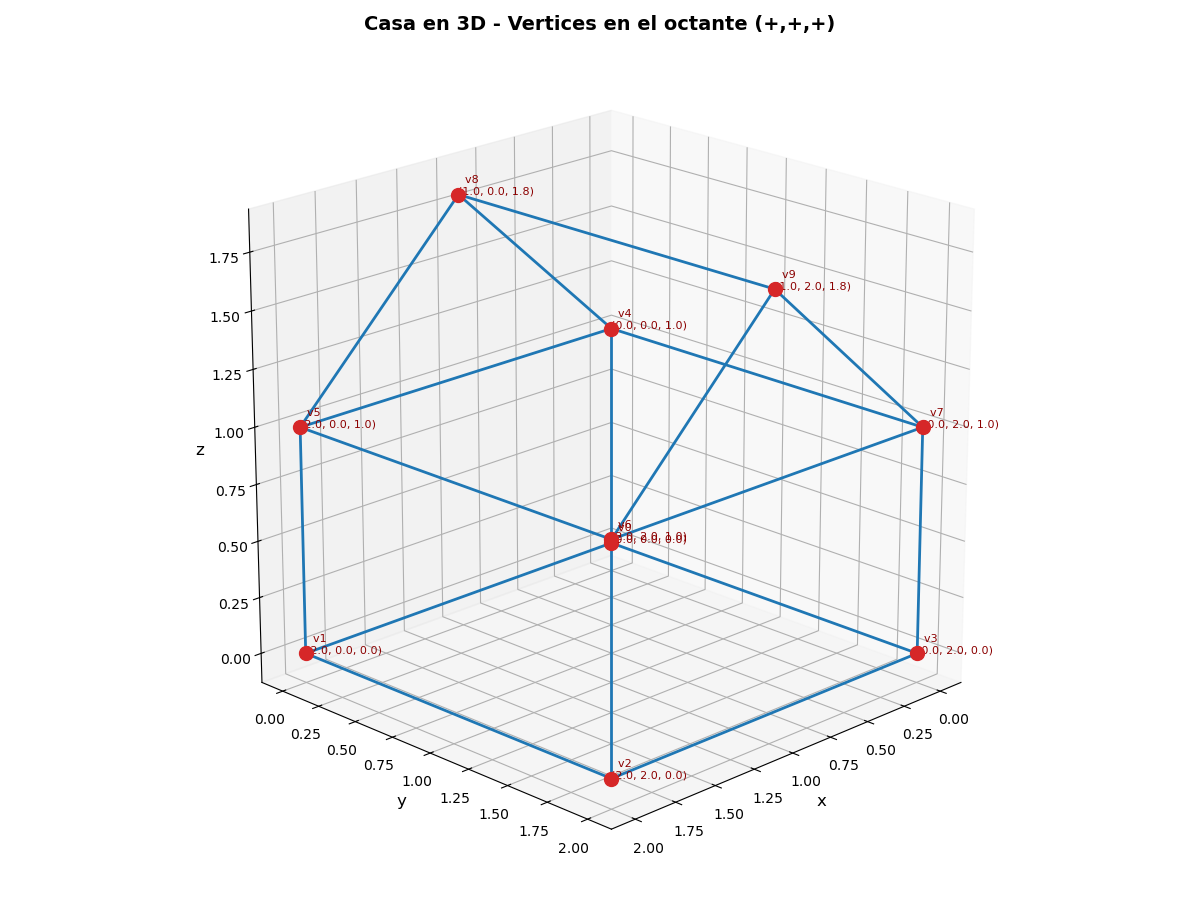

In [33]:
# Visualizacion estatica de la casa con puntos etiquetados
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Dibujar la casa
for i, j in E:
    x = [V[i, 0], V[j, 0]]
    y = [V[i, 1], V[j, 1]]
    z = [V[i, 2], V[j, 2]]
    ax.plot(x, y, z, color='tab:blue', linewidth=2)

# Dibujar puntos con etiquetas y coordenadas
for idx, point in enumerate(V):
    ax.scatter(*point, color='tab:red', s=100, zorder=5)
    coord_text = f'v{idx}\n({point[0]:.1f}, {point[1]:.1f}, {point[2]:.1f})'
    ax.text(point[0], point[1], point[2], f'  {coord_text}', fontsize=8, color='darkred')

ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_zlabel('z', fontsize=12)
ax.set_title('Casa en 3D - Vertices en el octante (+,+,+)', fontsize=14, fontweight='bold')
ax.view_init(elev=20, azim=45)
ax.grid(True, alpha=0.3)
ax.set_box_aspect((1, 1, 1))
plt.tight_layout()
plt.show()

---

# Sección 2: Análisis de Rango mediante Nubes de Puntos

En esta sección exploraremos cómo las transformaciones lineales afectan a conjuntos aleatorios de puntos en $\mathbb{R}^3$. 

**Objetivo**: Visualizar cómo matrices con diferentes rangos (1, 2 o 3) transforman una "nube desordenada" de puntos en estructuras geométricas claras (líneas, planos o espacios 3D).

**Concepto clave**: El rango de una matriz determina la dimensión del espacio en el que se proyectan los puntos transformados.

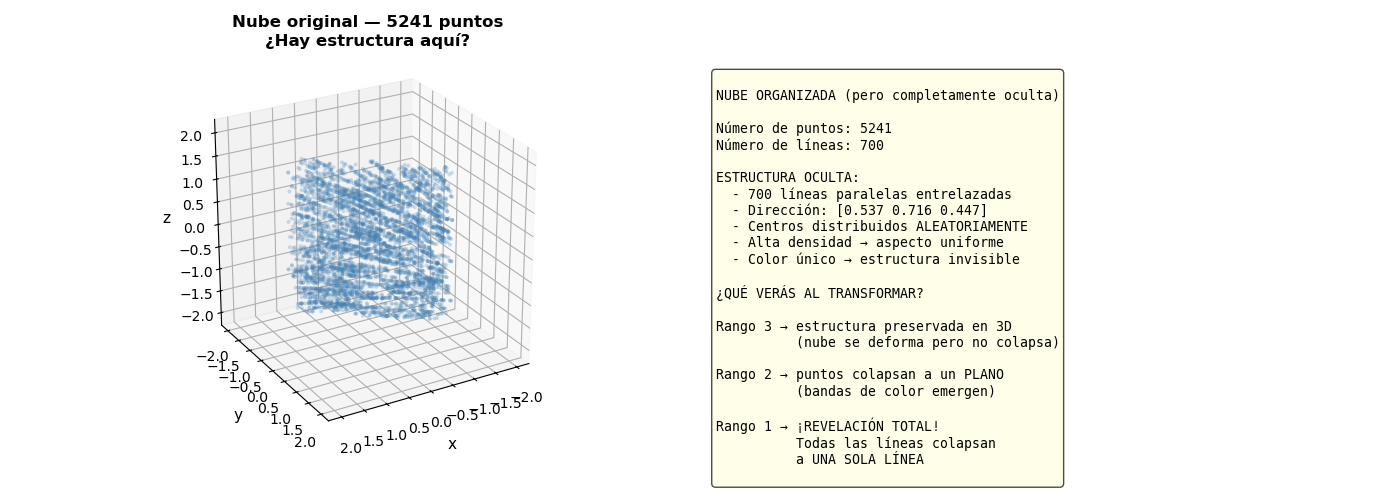

In [44]:

# -----------------------------------------------------------------------
# Nube con ESTRUCTURA COMPLETAMENTE OCULTA
#
# Estrategia: centros de líneas ALEATORIOS + alta densidad
#   → la nube se ve como una nube uniforme pero todas las líneas son paralelas
# -----------------------------------------------------------------------
np.random.seed(7)

# Dirección de las líneas (componentes balanceadas → sin eje dominante)
direccion = np.array([3.0, 4.0, 2.5])
direccion = direccion / np.linalg.norm(direccion)   # ~[0.52, 0.69, 0.43]

# Base ortonormal en el plano perpendicular a la dirección
e1 = np.array([-direccion[1], direccion[0], 0.0])
e1 = e1 / np.linalg.norm(e1)
e2 = np.cross(direccion, e1)
e2 = e2 / np.linalg.norm(e2)

# Centros ALEATORIOS en el plano perpendicular
# Spread reducido (1.5) → la mayoría de los puntos caben en el cubo [-2,2]^3
n_lineas = 700
spread   = 1.5
u_rand = np.random.uniform(-spread, spread, n_lineas)
v_rand = np.random.uniform(-spread, spread, n_lineas)
centros = np.outer(u_rand, e1) + np.outer(v_rand, e2)

# Puntos por línea pocos → los puntos no forman "rayas" continuas visibles
puntos_por_linea = 10
P_puntos = []
for linea_idx, centro in enumerate(centros):
    t_vals = np.random.uniform(-2.8, 2.8, puntos_por_linea)
    for t in t_vals:
        P_puntos.append(centro + t * direccion)

P = np.array(P_puntos)
linea_de_punto = np.repeat(np.arange(n_lineas), puntos_por_linea)

# Centrar y recortar al cubo [-2, 2]^3
P = P - P.mean(axis=0)
mascara = np.all(np.abs(P) <= 2.0, axis=1)
P = P[mascara]
linea_de_punto = linea_de_punto[mascara]

# ---- Visualización ------------------------------------------------
fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(P[:, 0], P[:, 1], P[:, 2],
            color='steelblue', alpha=0.25, s=8, edgecolors='none')
ax1.set_xlabel('x', fontsize=11)
ax1.set_ylabel('y', fontsize=11)
ax1.set_zlabel('z', fontsize=11)
ax1.set_title(f'Nube original — {len(P)} puntos\n¿Hay estructura aquí?',
              fontsize=12, fontweight='bold')
ax1.view_init(elev=25, azim=60)
ax1.grid(True, alpha=0.3)
ax1.set_box_aspect((1, 1, 1))

ax2 = fig.add_subplot(122)
ax2.axis('off')
stats_text = f"""
NUBE ORGANIZADA (pero completamente oculta)

Número de puntos: {len(P)}
Número de líneas: {n_lineas}

ESTRUCTURA OCULTA:
  - {n_lineas} líneas paralelas entrelazadas
  - Dirección: {np.round(direccion, 3)}
  - Centros distribuidos ALEATORIAMENTE
  - Alta densidad → aspecto uniforme
  - Color único → estructura invisible

¿QUÉ VERÁS AL TRANSFORMAR?

Rango 3 → estructura preservada en 3D
          (nube se deforma pero no colapsa)

Rango 2 → puntos colapsan a un PLANO
          (bandas de color emergen)

Rango 1 → ¡REVELACIÓN TOTAL!
          Todas las líneas colapsan
          a UNA SOLA LÍNEA
"""
ax2.text(0.05, 0.95, stats_text, fontsize=9.5, verticalalignment='top',
         fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

plt.tight_layout()
plt.show()


In [36]:
# Widgets para editar la matriz A (solo para la casa)
a11 = widgets.FloatText(value=1.0, description='a11')
a12 = widgets.FloatText(value=0.0, description='a12')
a13 = widgets.FloatText(value=0.0, description='a13')
a21 = widgets.FloatText(value=0.0, description='a21')
a22 = widgets.FloatText(value=1.0, description='a22')
a23 = widgets.FloatText(value=0.0, description='a23')
a31 = widgets.FloatText(value=0.0, description='a31')
a32 = widgets.FloatText(value=0.0, description='a32')
a33 = widgets.FloatText(value=1.0, description='a33')

def matriz_actual():
    return np.array([
        [a11.value, a12.value, a13.value],
        [a21.value, a22.value, a23.value],
        [a31.value, a32.value, a33.value],
    ], dtype=float)

# Octantes por signos (x, y, z)
octantes = {
    '(+,+,+)': ( 1,  1,  1),
    '(-,+,+)': (-1,  1,  1),
    '(+,-,+)': ( 1, -1,  1),
    '(+,+,-)': ( 1,  1, -1),
    '(-,-,+)': (-1, -1,  1),
    '(-,+,-)': (-1,  1, -1),
    '(+,-,-)': ( 1, -1, -1),
    '(-,-,-)': (-1, -1, -1),
}

selector_octante = widgets.Dropdown(
    options=list(octantes.keys()),
    value='(+,+,+)',
    description='Octante:'
)

btn_reflexion = widgets.Button(description='Cargar reflexion al octante', button_style='info')
btn_aplicar = widgets.Button(description='Aplicar y graficar', button_style='success')
salida = widgets.Output()

def cargar_reflexion(_):
    sx, sy, sz = octantes[selector_octante.value]
    a11.value, a12.value, a13.value = sx, 0.0, 0.0
    a21.value, a22.value, a23.value = 0.0, sy, 0.0
    a31.value, a32.value, a33.value = 0.0, 0.0, sz

def graficar(_=None):
    A = matriz_actual()
    VT = aplicar_transformacion(A, V)
    detA = np.linalg.det(A)

    with salida:
        clear_output(wait=True)
        fig = plt.figure(figsize=(12, 5))

        ax1 = fig.add_subplot(121, projection='3d')
        dibujar_casa(ax1, V, color='tab:blue', titulo='Casa original')

        ax2 = fig.add_subplot(122, projection='3d')
        dibujar_casa(ax2, VT, color='tab:red', titulo='Casa transformada')

        all_pts = np.vstack([V, VT])
        lim = np.max(np.abs(all_pts)) + 0.5
        for ax in (ax1, ax2):
            ax.set_xlim([-lim, lim])
            ax.set_ylim([-lim, lim])
            ax.set_zlim([-lim, lim])
            ax.view_init(elev=20, azim=35)
            ax.grid(True, alpha=0.35)

        plt.tight_layout()
        plt.show()

        print('Matriz A usada:')
        print(A)
        print(f'det(A) = {detA:.3f}')
        if detA < 0:
            print('Interpretacion: hay cambio de orientacion (incluye una reflexion).')
        elif detA == 0:
            print('Interpretacion: la transformacion colapsa dimensiones (no es invertible).')
        else:
            print('Interpretacion: conserva orientacion (sin reflexion pura).')

btn_reflexion.on_click(cargar_reflexion)
btn_aplicar.on_click(graficar)

fila1 = widgets.HBox([a11, a12, a13])
fila2 = widgets.HBox([a21, a22, a23])
fila3 = widgets.HBox([a31, a32, a33])
controles = widgets.VBox([
    widgets.HTML('<b>Matriz de transformacion A (para la casa)</b>'),
    fila1, fila2, fila3,
    selector_octante,
    widgets.HBox([btn_reflexion, btn_aplicar])
])

display(controles, salida)

# Grafica inicial
graficar()

Output()

In [45]:
# Widgets SEPARADOS para la nube de puntos (matriz B)
b11 = widgets.FloatText(value=1.0, description='b11')
b12 = widgets.FloatText(value=0.0, description='b12')
b13 = widgets.FloatText(value=0.0, description='b13')
b21 = widgets.FloatText(value=0.0, description='b21')
b22 = widgets.FloatText(value=1.0, description='b22')
b23 = widgets.FloatText(value=0.0, description='b23')
b31 = widgets.FloatText(value=0.0, description='b31')
b32 = widgets.FloatText(value=0.0, description='b32')
b33 = widgets.FloatText(value=1.0, description='b33')

def matriz_nube():
    return np.array([
        [b11.value, b12.value, b13.value],
        [b21.value, b22.value, b23.value],
        [b31.value, b32.value, b33.value],
    ], dtype=float)

btn_aplicar_nube = widgets.Button(description='Aplicar y graficar nube', button_style='success')
salida_nube = widgets.Output()

def graficar_nube(_=None):
    B = matriz_nube()
    PT = aplicar_transformacion(B, P)
    detB = np.linalg.det(B)
    rankB = np.linalg.matrix_rank(B)

    with salida_nube:
        clear_output(wait=True)
        fig = plt.figure(figsize=(16, 6))

        # ORIGINAL: Puntos coloreados por línea (estructura oculta)
        ax1 = fig.add_subplot(121, projection='3d')
        scatter1 = ax1.scatter(P[:, 0], P[:, 1], P[:, 2], c=linea_de_punto, 
                              cmap='tab20', alpha=0.8, s=15, edgecolors='k', linewidth=0.2)
        ax1.set_xlabel('x', fontsize=10)
        ax1.set_ylabel('y', fontsize=10)
        ax1.set_zlabel('z', fontsize=10)
        ax1.set_title('ORIGINAL: Puntos en líneas paralelas\n(estructura oculta)', 
                      fontsize=12, fontweight='bold')
        ax1.view_init(elev=20, azim=45)
        ax1.grid(True, alpha=0.3)
        ax1.set_box_aspect((1, 1, 1))
        plt.colorbar(scatter1, ax=ax1, label='Línea ID', shrink=0.8)

        # TRANSFORMADA: Mismos colores revelan la transformación
        ax2 = fig.add_subplot(122, projection='3d')
        scatter2 = ax2.scatter(PT[:, 0], PT[:, 1], PT[:, 2], c=linea_de_punto, 
                              cmap='tab20', alpha=0.8, s=15, edgecolors='k', linewidth=0.2)
        ax2.set_xlabel('x', fontsize=10)
        ax2.set_ylabel('y', fontsize=10)
        ax2.set_zlabel('z', fontsize=10)
        
        if rankB == 3:
            titulo = 'TRANSFORMADA: Estructura preservada\n(Rango 3 - Invertible)'
        elif rankB == 2:
            titulo = 'TRANSFORMADA: Estructura colapsa a plano\n(Rango 2 - Líneas → Plano)'
        elif rankB == 1:
            titulo = 'TRANSFORMADA: ¡ESTRUCTURA REVELADA!\n(Rango 1 - Líneas → Línea única)'
        else:
            titulo = 'TRANSFORMADA: Todo colapsa al origen\n(Rango 0)'
            
        ax2.set_title(titulo, fontsize=12, fontweight='bold', color='darkred' if rankB < 3 else 'black')
        ax2.view_init(elev=20, azim=45)
        ax2.grid(True, alpha=0.3)
        ax2.set_box_aspect((1, 1, 1))
        plt.colorbar(scatter2, ax=ax2, label='Línea ID', shrink=0.8)

        all_pts_nube = np.vstack([P, PT])
        lim_nube = np.max(np.abs(all_pts_nube)) + 0.5
        for ax in (ax1, ax2):
            ax.set_xlim([-lim_nube, lim_nube])
            ax.set_ylim([-lim_nube, lim_nube])
            ax.set_zlim([-lim_nube, lim_nube])

        plt.tight_layout()
        plt.show()

        print('Matriz B usada:')
        print(B)
        print(f'\ndet(B) = {detB:.3f}')
        print(f'rango(B) = {rankB}')
        if rankB == 3:
            print('→ Rango 3: Invertible. La estructura se preserva (nube de líneas paralelas).')
        elif rankB == 2:
            print('→ Rango 2: ESTRUCTURA PARCIALMENTE REVELADA.')
            print('   Las líneas paralelas colapsan a un PLANO.')
            print('   Puntos del mismo color se agrupan en bandas del plano.')
        elif rankB == 1:
            print('→ Rango 1: ¡¡ESTRUCTURA TOTALMENTE REVELADA!!')
            print('   ¡TENDENCIA MÁXIMA!')
            print('   Todas las líneas paralelas colapsan a UNA SOLA LÍNEA.')
            print('   Cada color representa puntos que vinieron de la misma línea original.')
        else:
            print('→ Rango 0: Transformación degenerada (todos al origen).')

btn_aplicar_nube.on_click(graficar_nube)

fila_b1 = widgets.HBox([b11, b12, b13])
fila_b2 = widgets.HBox([b21, b22, b23])
fila_b3 = widgets.HBox([b31, b32, b33])
controles_nube = widgets.VBox([
    widgets.HTML('<b>Matriz de transformacion B (para la nube de puntos)</b>'),
    fila_b1, fila_b2, fila_b3,
    btn_aplicar_nube
])

display(controles_nube, salida_nube)

# Grafica inicial
graficar_nube()

print("\n" + "=" * 80)
print("EXPERIMENTAR CON MATRICES - REVELA LA ESTRUCTURA OCULTA:")
print("=" * 80)
print("\n1. RANGO 2 (Estructura PARCIALMENTE revelada):")
print("   b11=1, b12=0, b13=0")
print("   b21=0, b22=1, b23=0")
print("   b31=0, b32=0, b33=0")
print("   → Las líneas paralelas colapsan a un PLANO")
print("   → Puntos con el mismo color forman bandas en el plano")

print("\n2. RANGO 1 (¡Estructura COMPLETAMENTE revelada!) ← MEJOR PARA VER TENDENCIA")
print("   b11=1, b12=1, b13=1")
print("   b21=1, b22=1, b23=1")
print("   b31=1, b32=1, b33=1")
print("   → ¡REVELACIÓN TOTAL!")
print("   → Todas las 8 líneas paralelas colapsan a UNA ÚNICA LÍNEA")
print("   → Cada color marca de dónde vinieron los puntos")
print("   → ¡TENDENCIA MÁXIMA Y MÁS CLARA!")

print("\n3. RANGO 3 (Estructura PRESERVADA, pero transformada):")
print("   b11=2, b12=0, b13=0")
print("   b21=0, b22=1.5, b23=0")
print("   b31=0, b32=0, b33=0.8")
print("   → Escalamiento: nube se expande/contrae")
print("   → Las líneas paralelas siguen siendo paralelas")
print("   → Estructura se preserva en 3D")

print("\n4. RANGO 2 (Proyección diagonal):")
print("   b11=1, b12=1, b13=0")
print("   b21=0, b22=0, b23=0")
print("   b31=0, b32=0, b33=1")
print("   → Colapso diagonal a un plano")
print("   → Estructura se comprime a 2D")
print("=" * 80)

Output()


EXPERIMENTAR CON MATRICES - REVELA LA ESTRUCTURA OCULTA:

1. RANGO 2 (Estructura PARCIALMENTE revelada):
   b11=1, b12=0, b13=0
   b21=0, b22=1, b23=0
   b31=0, b32=0, b33=0
   → Las líneas paralelas colapsan a un PLANO
   → Puntos con el mismo color forman bandas en el plano

2. RANGO 1 (¡Estructura COMPLETAMENTE revelada!) ← MEJOR PARA VER TENDENCIA
   b11=1, b12=1, b13=1
   b21=1, b22=1, b23=1
   b31=1, b32=1, b33=1
   → ¡REVELACIÓN TOTAL!
   → Todas las 8 líneas paralelas colapsan a UNA ÚNICA LÍNEA
   → Cada color marca de dónde vinieron los puntos
   → ¡TENDENCIA MÁXIMA Y MÁS CLARA!

3. RANGO 3 (Estructura PRESERVADA, pero transformada):
   b11=2, b12=0, b13=0
   b21=0, b22=1.5, b23=0
   b31=0, b32=0, b33=0.8
   → Escalamiento: nube se expande/contrae
   → Las líneas paralelas siguen siendo paralelas
   → Estructura se preserva en 3D

4. RANGO 2 (Proyección diagonal):
   b11=1, b12=1, b13=0
   b21=0, b22=0, b23=0
   b31=0, b32=0, b33=1
   → Colapso diagonal a un plano
   → Estruc

## Actividades propuestas

### Sección 1: Ejercicio de la Casa

#### Parte 1A: Reflexiones y Determinante
1. **Reflexiones**: Carga la reflexión hacia cada octante usando el botón "Cargar reflexión". Describe qué coordenadas cambian de signo en cada caso. ¿Qué relación existe entre el octante elegido y los signos en la diagonal de $A$?

2. **Determinante y orientación**: Calcula $\det(A)$ para cada reflexión. Observa el signo del determinante. ¿Qué patrón encuentras? ¿Cómo se relaciona el signo del determinante con la orientación de la casa?

#### Parte 1B: Transformaciones especiales
3. **Cizalla**: Ingresa una matriz de cizalla, por ejemplo $A = \begin{pmatrix} 1 & 1 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 1 \end{pmatrix}$.
   - ¿Qué transformación realiza en la casa?
   - ¿Cuánto vale $\det(A)$? ¿Es invertible?

4. **Escalamiento**: Usa $A = \mathrm{diag}(2, 1.5, 0.8)$.
   - ¿Qué ocurre con la casa?
   - ¿Cómo cambia el signo de $\det(A)$?

#### Parte 1C: Síntesis
5. **Invertibilidad**: Encuentra una matriz que sea **invertible** y desplace la casa al octante $(-,-,+)$ sin colapsar la figura. Verifica que $\det(A) \neq 0$.

6. **Recuperación**: Una vez aplicada una transformación invertible, ¿cómo recuperarías la casa original? Describe el procedimiento y prueba ingresando manualmente los valores de $A^{-1}$.

---

### Sección 2: Ejercicio de Análisis de Rango (Nube de Puntos)

#### Parte 2A: Rango e invertibilidad
7. **Rango 1 - Colapso a línea**: Utiliza la matriz $B = \begin{pmatrix} 1 & 1 & 1 \\ 1 & 1 & 1 \\ 1 & 1 & 1 \end{pmatrix}$ ingresando estos valores en los campos b11, b12, ..., b33. 
   - ¿Qué ocurre con la nube? ¿Cuál es $\det(B)$? 
   - ¿Es invertible? Explica por qué.

8. **Rango 2 - Colapso a plano**: Prueba la matriz diagonal $B = \mathrm{diag}(1, 1, 0)$.
   - ¿Qué dimensión se pierde? 
   - ¿Es invertible? Calcula el determinante.
   - ¿En qué plano colapsan los puntos?

9. **Rango 3 - Transformación invertible**: Prueba $B = \begin{pmatrix} 2 & 0.5 & 0 \\ 0 & 1.5 & 0 \\ 0 & 0 & 1 \end{pmatrix}$.
   - Observa el efecto. ¿Se preserva la estructura de la nube o cambia radicalmente?
   - ¿Es invertible? ¿Cuál es el signo de $\det(B)$?

#### Parte 2B: Exploración y síntesis
10. **Comparación de rangos**: En una tabla, resume qué ocurre con la nube para rango 1, 2 y 3. Incluye el determinante en cada caso.

11. **Estructura geométrica revelada**: La nube "desordenada" original revela su estructura cuando se aplica una transformación con rango < 3. Explica geométricamente por qué esto sucede.

12. **Síntesis final**: Escribe un párrafo explicando la relación entre rango, determinante e invertibilidad de una matriz, usando ejemplos geométricos de cómo transforman la nube de puntos.
